# `Материалы кафедры ММП факультета ВМК МГУ. Введение в глубокое обучение.`

## `Задание 3.5. Трансформеры для Named Entity Recognition`

#### Фамилия, имя:

Дата выдачи: <span style="color:red">__10 апреля 23:00__</span>.

Мягкий дедлайн: <span style="color:red">__21 апреля 03:00__</span>.

Стоимость: __10 баллов__ (основная часть заданий)

<span style="color:red">__В ноутбуке все клетки должны выполняться без ошибок при последовательном их выполнении.__</span>

#### `Москва, 2026`

В рамках этого задания вы научитесь:
1. Загружать датасеты и претренированные модели из [Hugging face Hub](https://huggingface.co)
2. Манипулировать текстовыми датасетами с помощью библиотеки [datasets](https://huggingface.co/docs/datasets/index)
3. Запускать и обучать трансформеры с помощью библиотеки [transformers](https://huggingface.co/docs/transformers/index)
4. Промптить большую языковую модель на примере [Qwen3.5-4B](https://huggingface.co/Qwen/Qwen3.5-4B)
5. Оптимизировать гиперпараметры с помощью библиотеки [optuna](https://optuna.org/)

При выполнении задания вы будете решать стандартную задачу классификации токенов, в частности распознавание именованных сущностей.

Задание состоит из трёх частей:
1. Обработка данных и работа датасетами из Hugging Face.
2. Практика больших языковых моделей.
3. Дообучение трансформера.

Обратите свое вниманимание на [официальный гайд](https://huggingface.co/learn/nlp-course/chapter7/2), в котором подробно разбирается задача классификации токенов.

## `Часть 1. Загрузка и предобработка (4 балла)`

### `Подготовка среды Kaggle`

**Хранение ключей**: Kaggle Secrets --- инструмент для безопасного хранения и использования в ноутбуках Kaggle API-ключей, паролей или токенов.

Для добавления нового ключа:
1. Перейдите в Add-ons --> secrets
2. Add secret для добавления нового ключа. Доступ к ключу из ноутбука осуществляется с помощью пакета kaggle_secrets
3. Коллекция ключей общая для всех ноутбуков пользователя на kaggle. Но в каждом ноутбуке необходимо выбрать ключи, которые будут доступны через kaggle_secrets

Ниже находится пример подгрузки ключей для kaggle и wandb.

In [1]:
# from kaggle_secrets import UserSecretsClient
# import os

# api_keys = UserSecretsClient()

# os.system(f"huggingface-cli login --token {api_keys.get_secret('huggingface-cli')}")
# os.system(f"wandb login {api_keys.get_secret('wandb')}")

**Установка домашнего каталога**: Если мы хотим контролировать путь, по которому будут загружаться датасеты, чекпоинты моделей и т.д., то стоит задать переменную среды `HF_HOME`. При использовании kaggle перемещение домашнего каталога huggingface в директорию working позволит избежать повторной загрузки при перезапуске ноутбука (не забудьте установить "persistence: files only" в настройках kaggle-ноутбука)

In [2]:
# Optional

# os.environ['HF_HOME'] = '/kaggle/working/hf_hub'

### `Подготовка среды Google Colab`

Секреты можно настроить в колабе:

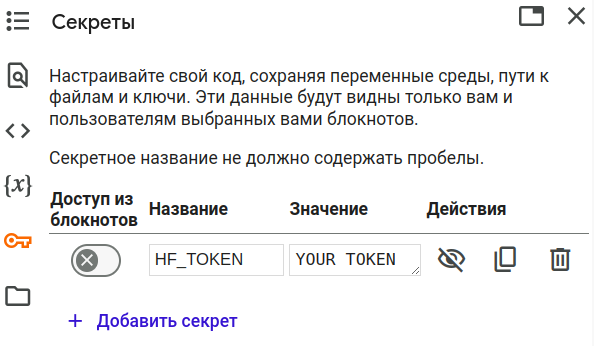

### `Установка зависимостей`

In [ ]:
# pip offers the --quiet / -q option to silence output

! uv pip install -q "transformers[torch]==5.2.0" "outlines==1.2.12" datasets evaluate seqeval optuna

При работе с библиотеками часто бывает важно соблюдение версий. Задание тестировалось при версиях библиотек указанных ниже.

In [4]:
! uv pip freeze > requirements.txt
!cat requirements.txt | grep torch

Using Python 3.12.13 environment at: /usr
torch==2.10.0+cu128
torchao==0.10.0
torchaudio==2.10.0+cu128
torchcodec==0.10.0+cu128
torchdata==0.11.0
torchsummary==1.5.1
torchtune==0.6.1
torchvision==0.25.0+cu128


In [35]:
!cat requirements.txt | grep transformers
!cat requirements.txt | grep datasets
!cat requirements.txt | grep evaluate
!cat requirements.txt | grep seqeval
!cat requirements.txt | grep optuna
!cat requirements.txt | grep outlines

sentence-transformers==5.3.0
transformers==5.2.0
datasets==4.0.0
tensorflow-datasets==4.9.9
vega-datasets==0.9.0
evaluate==0.4.6
seqeval==1.2.2
optuna==4.8.0
outlines==1.2.12
outlines-core==0.2.14


In [ ]:
import gc
import json
import random
from typing import Any, Literal
from pathlib import Path

from abc import abstractmethod, ABC

import numpy as np
import numpy.typing as npt

import torch
import datasets
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    pipeline,
    DataCollatorForTokenClassification,
    TrainingArguments,
    Trainer,
    AutoModelForCausalLM,
    PreTrainedModel, PreTrainedTokenizer,
)
from transformers.trainer_callback import EarlyStoppingCallback
from huggingface_hub import snapshot_download

import optuna
import evaluate
import outlines
from pydantic import BaseModel, Field, model_validator
from dataclasses import dataclass

torch.backends.cudnn.benchmark = True
torch.use_deterministic_algorithms(False)

torch.autograd.profiler.profile(False)
torch.autograd.profiler.emit_nvtx(False)
torch.autograd.set_detect_anomaly(False)

torch.set_float32_matmul_precision('high')
torch.backends.cuda.matmul.allow_tf32 = True

In [2]:
def set_global_seed(seed: int) -> None:
    """Set global seed for reproducibility.
    :param int seed: Seed to be set
    """
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def print_params_count(model):

    total_params = sum(p.numel() for p in model.parameters())
    total_params_grad = sum(p.numel() for p in model.parameters() if p.requires_grad)

    model_name = model.__class__.__name__
    print(f"Информация о числе параметров модели: {model_name}")
    print(f"Всего параметров: \t\t {total_params}")
    print(f"Всего обучаемых параметров: \t {total_params_grad}")
    print()

set_global_seed(42)

На протяжении всего задания вы можете добавлять любой `import`, иногда, это и являются частью задания. При работе с большими библиотеками очень важно уметь читать документацию и использовать гугл для поиска информации.

Для выполнения задания необходимо использование GPU!

In [3]:
if not torch.cuda.is_available():
    print("You need GPU!!!")

### `Загрузка данных (0.25 балла)`

В первую очередь, Hugging Face --- это хаб с датасетами и моделями. Загрузите готовый датасет [отсюда](https://huggingface.co/datasets/voorhs/conll2003-corrupted).

Подсказка: почитайте [туториал](https://huggingface.co/docs/datasets/load_hub).

*Если не получится сразу, то лучше перед следующими попытками перезапустить ноутбук.*

In [ ]:
# YOUR CODE IS HERE

DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 14041
    })
    validation: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3250
    })
    test: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3453
    })
})

**Вопрос**: Какие поля нам доступны? Напечатайте пару примеров из каждого сплита. Попытайтесь догадаться какой смысл имеет каждое поле и опишите в двух словах.

*Подсказка:* почитайте [туториал](https://huggingface.co/docs/datasets/access).

In [11]:
# YOUR CODE IS HERE

**Ответ:** *интересно что же вы напишете сюда*

### `Удаление колонок (0.25 балла)`

Мы будем предсказывать NER tags непосредственно по тексту. Остальная информация нам не понадобится. Удалите все колонки кроме `tokens` и `ner_tags`.

*Подсказка:* почитайте [туториал](https://huggingface.co/docs/datasets/process#remove).

In [ ]:
# YOUR CODE IS HERE
dataset_raw_essential = ...

DatasetDict({
    train: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 14041
    })
    validation: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 3250
    })
    test: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 3453
    })
})

### `Сбор тегов (0.25 балла)`

Обратите внимание,что в датасете представлена **BIO-разметка**.

**BIO-разметка** -- это способ аннотации текста для распознавания именованных сущностей (NER), где **B** (Beginning) обозначает начало сущности, **I** (Inside) — продолжение той же сущности, а **O** (Outside) — отсутствие сущности.

Например, в предложении *"Apple выпустила новый iPhone"* разметка будет: *"Apple/B-ORG выпустила/O новый/O iPhone/B-PRODUCT"*.

В предложении  *"Билл Гейтс основал Microsoft"* -- *"Билл/B-PER Гейтс/I-PER основал/O Microsoft/B-ORG"*.

**Такой формат помогает моделям точно определять границы и типы сущностей.**



Прежде чем работать с датасетом, необходимо понять, какие именно NER-теги присутствуют в данных. Напечатайте все уникальные значения NER-тегов, которые встречаются в датасете.

*Подсказка:* по датасету можно итерироваться с помощью конструкции `for ... in`

**Вопрос:**
- есть ли какие-то подозрительные теги, которых быть не должно?

In [ ]:
# YOUR CODE IS HERE

['B-LOC',
 'B-MISC',
 'B-ORG',
 'B-PER',
 'I-LOC',
 'I-MISC',
 'I-ORG',
 'I-PER',
 'MISSING',
 'O']

Для вычисления лосс функции и подсчета метрик нам потребуется перевести теги в классы, так как мы будем решать задачу классификации.

Создайте мапинги тегов:
- `label2id`: строковое представление тега (например `B-PER`) -> индекс класса
- `id2label`: наоборот

Исключите из них подозрительные теги, которых не должно быть.

*Подсказка:* должно получиться 9 тегов

In [ ]:
# YOUR CODE IS HERE
id2label = ...

['B-LOC', 'B-MISC', 'B-ORG', 'B-PER', 'I-LOC', 'I-MISC', 'I-ORG', 'I-PER', 'O']

In [15]:
label2id = {name: i for i, name in enumerate(id2label)}
label2id

{'B-LOC': 0,
 'B-MISC': 1,
 'B-ORG': 2,
 'B-PER': 3,
 'I-LOC': 4,
 'I-MISC': 5,
 'I-ORG': 6,
 'I-PER': 7,
 'O': 8}

### `Фильтрация (0.25 балла)`

В обучающей выборке для части объектов пропущена разметка. Разделите обучающую выборку на размеченные и неразмеченные объекты. Напечатайте размеры обеих частей.

*Подсказка:* прочитайте [туториал](https://huggingface.co/docs/datasets/process#select-and-filter). Фильрацию датасета можно написать в одну строчку.

In [ ]:
# YOUR CODE IS HERE

DatasetDict({
    train: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 10000
    })
    validation: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 3250
    })
    test: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 3453
    })
    train_missing: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 4041
    })
})

In [17]:
assert len(dataset_raw_essential["train_missing"]) == 4041

### `Получение tokenizer-independent представления (2 балла)`

Имеющаяся BIO-разметка построена для токенизатора, который нам, к сожалению, **не известен**. Необходимо построить tokenizer-independent представление нашего датасета.

**Восстановление текста**: Для каждого объекта датасета необходимо объединить токены из `tokens` в единую строку и поместить в поле `text`. Необходимо учесть, что знаки препинания, кавычки и скобки (например, `,`, `.`, `!`. `)`, `"`) не должны иметь пробелов перед собой, но должны иметь пробел после себя.

**Изменение BIO-разметки**: Так как каждый токенизатор по-своему разобьет полученный `text`, то необходимо уметь строить BIO-разметку для любого токенизатора.

По имеющейся BIO-разметке необходимо:
* Оставить только последовательность сущностей, удалив префиксы начала (B- и I-).
* Для каждой именованной сущности найти позиции символов, ей соответствующие (в формате python slice).

Пример результата:
```python
{
    'text': '6 - Andre Agassi (U.S.) vs. Mauricio Hadad (Colombia)',
    'tags': ['PER', 'LOC', 'PER','LOC'],
    'ranges': [[4, 16], [19, 23], [30, 44], [47, 55]]
}
```

*Пояснение к примеру*. В тексте `'6 - Andre Agassi (U.S.) vs. Mauricio Hadad (Colombia)'` встретилось четыре сущности:
- `PER` на позициях `[4,16]`, а именно `Andre Agassi`
- `LOC` на позициях `[19,23]`, а именно `U.S.`
- `PER` на позициях `[30,44]`, а именно `Mauricio Hadad`
- `LOC` на позициях `[47,55]`, а именно `Colombia`

**Важно:**
- Полученный результат сохраните на диск (например по пути `./data/generic`)
- Подробности о названиях аргументов и возвращаемых значениях берите из докстринга функции `transform_ner_data`

In [ ]:
def transform_ner_data(tokens: list[str], ner_tags: list[str]):
    """
    Obtain tokenizer-independent representation of a single sample.

    Args:
        tokens: list of words, subwords or even punctuations
        ner_tags: list of BIO labels
    Returns:
        sample: dictionary with the following contents:
            - text (str): detokenized sequence
            - tags (list[str]): list of tags names (PER, ORG, LOC, MISC)
            - ranges (list[tuple[int, int]]): list of python slices for each entity
    """

    punctuation_symbols = ("-", "'", ".", ",", "(", ")", ":", ";", '"')

    # YOUR CODE IS HERE
    text = ""
    ranges = []
    tags = []

    # Final output
    return {"text": text, "tags": tags, "ranges": ranges}

Проверьте, что все работает:

In [19]:
dataset_generic = dataset_raw_essential.map(
    function=transform_ner_data,
    input_columns=["tokens", "ner_tags"],
    remove_columns=dataset_raw_essential["train"].column_names,
    load_from_cache_file=False,
)

dataset_generic

Map: 100%|##########| 10000/10000 [00:00<?, ? examples/s]

Map: 100%|##########| 3250/3250 [00:00<?, ? examples/s]

Map: 100%|##########| 3453/3453 [00:00<?, ? examples/s]

Map: 100%|##########| 4041/4041 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'tags', 'ranges'],
        num_rows: 10000
    })
    validation: Dataset({
        features: ['text', 'tags', 'ranges'],
        num_rows: 3250
    })
    test: Dataset({
        features: ['text', 'tags', 'ranges'],
        num_rows: 3453
    })
    train_missing: Dataset({
        features: ['text', 'tags', 'ranges'],
        num_rows: 4041
    })
})

In [20]:
print(dataset_generic["train"][:10])

{'text': ['LONDON 1996-08-22', 'WorldCom, which said it will buy MFS, shed 1-3/4 to close at 21 while MFS lost 3-8/16 to close at 41-5/16.', '6- Andre Agassi( U.S.) vs. Mauricio Hadad( Colombia)', '" We\'ve always taken the view that we are the sort of company that\'s quite capable of working in difficult circumstances-- we\'re rather used to it.', 'Extras( lb-4 w-10 nb-7) 21', 'He appeared to have been killed on Tuesday night, suffering at least eight stab wounds.', '9. Johan Capiot( Belgium) Collstrop 32', "Honda's Takeda was pursued past Corser by the Yamaha duo of Noriyuki Haga and Wataru Yoshikawa with Haga briefly taking the lead in the final chicane on the last lap.", 'Eager to put Lauck behind bars quickly and avoid a long and complex trial, prosecutor Bernd Mauruschat limited his charges to offences since 1994.', '1-0.'], 'tags': [['LOC'], ['ORG', 'ORG', 'ORG'], ['PER', 'LOC', 'PER', 'LOC'], [], [], [], ['PER', 'LOC', 'ORG'], ['ORG', 'PER', 'PER', 'ORG', 'PER', 'PER', 'PER'], 

In [21]:
assert dataset_generic["train"][:10] == {
    'text': [
        'LONDON 1996-08-22',
        'WorldCom, which said it will buy MFS, shed 1-3/4 to close at 21 while MFS lost 3-8/16 to close at 41-5/16.',
        '6- Andre Agassi( U.S.) vs. Mauricio Hadad( Colombia)',
        '" We\'ve always taken the view that we are the sort of company that\'s quite capable of working in difficult circumstances-- we\'re rather used to it.',
        'Extras( lb-4 w-10 nb-7) 21', 'He appeared to have been killed on Tuesday night, suffering at least eight stab wounds.',
        '9. Johan Capiot( Belgium) Collstrop 32',
        "Honda's Takeda was pursued past Corser by the Yamaha duo of Noriyuki Haga and Wataru Yoshikawa with Haga briefly taking the lead in the final chicane on the last lap.",
        'Eager to put Lauck behind bars quickly and avoid a long and complex trial, prosecutor Bernd Mauruschat limited his charges to offences since 1994.', '1-0.'
    ],
    'tags': [
        ['LOC'],
        ['ORG', 'ORG', 'ORG'],
        ['PER', 'LOC', 'PER', 'LOC'],
        [],
        [],
        [],
        ['PER', 'LOC', 'ORG'],
        ['ORG', 'PER', 'PER', 'ORG', 'PER', 'PER', 'PER'],
        ['PER', 'PER'],
        []
    ], 'ranges': [
        [[0, 6]],
        [[0, 8], [33, 36], [70, 73]],
        [[3, 15], [17, 21], [27, 41], [43, 51]],
        [],
        [],
        [],
        [[3, 15], [17, 24], [26, 35]],
        [[0, 5], [8, 14], [32, 38], [46, 52], [60, 73], [78, 94], [100, 104]],
        [[13, 18], [86, 102]],
        []
    ]
}

Сохраните результат на диск:

In [21]:
# YOUR CODE IS HERE
dataset_generic.save_to_disk("./data/generic")

Saving the dataset (0/1 shards):   0%|          | 0/10000 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/3250 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/3453 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/4041 [00:00<?, ? examples/s]

### `Токенизация (1 балл)`

Для отладки воспользуемся токенизатором модели `google-bert/bert-base-uncased`.

In [ ]:
bert_tokenizer = AutoTokenizer.from_pretrained("google-bert/bert-base-uncased")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [23]:
print(bert_tokenizer(dataset_generic["train"]["text"][11]))

{'input_ids': [101, 3078, 3707, 6434, 2001, 27502, 1010, 6352, 11000, 1010, 2403, 1012, 1019, 3867, 2062, 2084, 2197, 2251, 1998, 1014, 1012, 1015, 3867, 2062, 2084, 1999, 2238, 1012, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


У каждого токенизатора есть свои специальные токены, для получения этой информации можно воспользоваться соотвествующей переменной.

In [24]:
bert_tokenizer.all_special_ids

[100, 102, 0, 101, 103]

Теперь надо написать функцию, которая по имеющуемуся tokenizer-independent представлению выдает BIO-разметку для предоставленного токенизатора.  Реализуйте функцию `align_tokens_and_tags`, которая трансформирует один объект из датасета. Все подробности о формате входных данных берите из докстринга.

**Важно:** служебные токены, добавляемые токенизатором должны иметь специальный лейбл `SPECIAL_TOKENS_LABEL`, т.к. их не надо учитывать при сборе лосса.

In [ ]:
SPECIAL_TOKENS_LABEL = -100


def align_tokens_and_tags(
    text: str, tags: list[str], ranges: list[tuple[int, int]], tokenizer: AutoTokenizer
):
    """
    Align the tokenizer-independent representation with a Hugging Face tokenizer.

    Args:
        text: original text.
        tags: list of entity tags (e.g., ["PER", "LOC"]).
        ranges: list of (start, end) character ranges for each entity.
        tokenizer: A Hugging Face tokenizer.

    Returns:
        dict: A dictionary with `input_ids`, `labels`:
            - input_ids are tokens indices in tokenizer's vocabulary
            - labels are integer labels for BIO tags (from label2id mapping)

    Note:
        This function
    """
    encoding = tokenizer(
        text, return_offsets_mapping=True, truncation=True, padding=False
    )
    tokens = tokenizer.convert_ids_to_tokens(encoding["input_ids"])
    token_ids = encoding["input_ids"]
    offset_mapping = encoding["offset_mapping"]

    # Initialize BIO tags for each token
    ner_tags = ["O"] * len(tokens)

    # YOUR CODE IS HERE

    return {
        "input_ids": token_ids,
        "labels": [
            SPECIAL_TOKENS_LABEL if token_id in tokenizer.all_special_ids else label2id[lab]
            for lab, token_id in zip(ner_tags, token_ids, strict=True)
        ],
    }

In [8]:
def tokenize_ner_dataset(
    dataset: datasets.DatasetDict | datasets.Dataset, tokenizer: AutoTokenizer
):
    return dataset.map(
        function=align_tokens_and_tags,
        input_columns=["text", "tags", "ranges"],
        fn_kwargs={"tokenizer": tokenizer},
        remove_columns=(
            dataset["train"] if "train" in dataset else dataset
        ).column_names,
    )

Вот пара примеров того, что должно получиться:

In [27]:
for i in range(9, 12):
    sample = dataset_generic["train"][i]
    print("before tokenization:", sample)
    tokenized_sample = align_tokens_and_tags(**sample, tokenizer=bert_tokenizer)
    print("after tokenization:", tokenized_sample)
    print()

before tokenization: {'text': '1-0.', 'tags': [], 'ranges': []}
after tokenization: {'input_ids': [101, 1015, 1011, 1014, 1012, 102], 'labels': [-100, 8, 8, 8, 8, -100]}

before tokenization: {'text': 'Puchon 3 Chonan 0( halftime 1-0)', 'tags': ['ORG', 'ORG'], 'ranges': [[0, 6], [9, 15]]}
after tokenization: {'input_ids': [101, 16405, 24561, 1017, 16480, 7229, 1014, 1006, 22589, 1015, 1011, 1014, 1007, 102], 'labels': [-100, 2, 6, 8, 2, 6, 8, 8, 8, 8, 8, 8, 8, -100]}

before tokenization: {'text': 'Primary iron output was 297,700 tonnes, 14.5 percent more than last July and 0.1 percent more than in June.', 'tags': [], 'ranges': []}
after tokenization: {'input_ids': [101, 3078, 3707, 6434, 2001, 27502, 1010, 6352, 11000, 1010, 2403, 1012, 1019, 3867, 2062, 2084, 2197, 2251, 1998, 1014, 1012, 1015, 3867, 2062, 2084, 1999, 2238, 1012, 102], 'labels': [-100, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, -100]}



Тесты:

In [28]:
dataset_tokenized = tokenize_ner_dataset(dataset_generic, bert_tokenizer)

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/3250 [00:00<?, ? examples/s]

Map:   0%|          | 0/3453 [00:00<?, ? examples/s]

Map:   0%|          | 0/4041 [00:00<?, ? examples/s]

In [29]:
assert dataset_tokenized["train"][5:7] == {
    "input_ids": [
        [
            101,
            2002,
            2596,
            2000,
            2031,
            2042,
            2730,
            2006,
            9857,
            2305,
            1010,
            6114,
            2012,
            2560,
            2809,
            17079,
            8710,
            1012,
            102,
        ],
        [
            101,
            1023,
            1012,
            13093,
            6178,
            25185,
            1006,
            5706,
            1007,
            8902,
            4877,
            13181,
            2361,
            3590,
            102,
        ],
    ],
    "labels": [
        [-100, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, -100],
        [-100, 8, 8, 3, 7, 7, 8, 0, 8, 2, 6, 6, 6, 8, -100],
    ],
}

## `Часть 2. Доразметка с помощью LLM (2 балла)`

Наконец, обратимся к трансфомерам! Причем сразу к большим.

Мы воспользуемся моделью `Qwen3.5` на 4 миллиарда параметров.

In [ ]:
class Mention(BaseModel):
    entity: str = Field(description="String literal from the original text referring to some entity.")
    tag: Literal["PER", "LOC", "ORG", "MISC"] = Field(description="Specific NER tag.")

class NERLabeling(BaseModel):
    reasoning: str = Field(description="Short preliminary speculations on the answer. 100-200 tokens max")
    text: str = Field(description="Original text to find entities within.")
    mentions: list[Mention] = Field(description="The entities found within the text.")

    @model_validator(mode="after")
    def validate_entities(self):
        for mention in self.mentions:
            if mention.entity not in self.text:
                raise ValueError(
                    f"Invalid mention: {mention}. No corresponding "
                    "substring found in the original text."
                )
        return self

In [ ]:
class Generator(ABC):

    @abstractmethod
    def generate_plain(self, query: str) -> str: ...

    def generate(self, query: str) -> NERLabeling:
        response = self.generate_plain(query)
        start_dict = response.find("{")
        end_dict = response.rfind("}")
        return NERLabeling.model_validate_json(response[start_dict : end_dict + 1])

### `Промт инжиниринг`

Для удобства парсинга, мы будем просить LLM возвращать ответы сразу в формате `json` словаря.

Напишите промт, в котором перечислите и опишите поля словаря, которые вы хотите получать от LLM.

**Важно:** скорее всего, вы будете возвращаться к этому заданию и редактировать промт, чтобы улучшить качество дальшейших шагов.

In [ ]:
def messages_maker(text: str) -> list[dict[str, str]]:
    """
    Creates a prompt for the LLM inference to generate NER labels.

    Args:
        text: The input text to be labeled.
    Returns:
        list: A list of messages formatted for the LLM inferemce.
    """
    system_message = (
        "You are an expert in Named Entity Recognition (NER). Your task is to analyze the given text and identify "
        "entities such as persons (PER), locations (LOC), organizations (ORG), and miscellaneous (MISC). "
        "You must return the results in a specific JSON format with the following fields: "
        "The 'reasoning' field should contain all your initial thoughts for solving NER task. "
        ##############
        # YOUR PROMPT
        ##############
    )

    user_message = f"Please analyze the following text and generate the NER labels as described:\n\n{text}"

    messages = [
        {"role": "system", "content": system_message},
        {"role": "user", "content": user_message},
    ]

    return messages

Для обработки одного примера будем использовать функцию `generate_answer`.

**Важно:** чтобы понимать, как это работает, почитайте [туториал](https://huggingface.co/docs/transformers/main/en/conversations#textgenerationpipeline).

In [33]:
class JSONGenerator(Generator):
    def __init__(self, model_name: str) -> None:
        self.generator = pipeline(model=model_name, task="text-generation", device="cuda")

    def generate_plain(self, query: str) -> str:
        chat = self.generator(messages_maker(query), max_new_tokens=1024)[0]["generated_text"]
        return chat[-1]["content"]


Эта функция отправляет текстовый запрос `query` большой языковой модели и возвращает ответ:

In [34]:
model_name = "Qwen/Qwen3.5-4B"

In [ ]:
# Download the model without loading it into RAM/VRAM
snapshot_download(repo_id=model_name)

Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

'/root/.cache/huggingface/hub/models--Qwen--Qwen3.5-4B/snapshots/851bf6e806efd8d0a36b00ddf55e13ccb7b8cd0a'

In [36]:
generator = JSONGenerator(model_name)

print(type(generator.generator))

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/426 [00:00<?, ?it/s]

<class 'transformers.pipelines.text_generation.TextGenerationPipeline'>


In [37]:
print_params_count(generator.generator.model)

Информация о числе параметров модели: Qwen3_5ForCausalLM
Всего параметров: 		 4205751296
Всего обучаемых параметров: 	 4205751296



In [38]:
print(generator.generate_plain("I live in London, but my father is from Germany."))

Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=1024) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Thinking Process:

1.  **Analyze the Request:**
    *   Task: Named Entity Recognition (NER).
    *   Input Text: "I live in London, but my father is from Germany."
    *   Output Format: JSON with specific schema (`$defs`, `properties`, `required`).
    *   Fields: `reasoning` (string), `text` (string), `mentions` (array of objects with `entity` and `tag`).
    *   Tags: `PER` (Person), `LOC` (Location), `ORG` (Organization), `MISC` (Miscellaneous).

2.  **Analyze the Input Text:**
    *   Sentence 1: "I live in London, but my father is from Germany."
    *   Potential Entities:
        *   "I": Pronoun, not a named entity.
        *   "London": City/Location. -> Tag: `LOC`.
        *   "father": Common noun, not a specific name. -> Not an entity.
        *   "Germany": Country/Location. -> Tag: `LOC`.

3.  **Draft Reasoning:**
    *   Scan the text for names of people, places, organizations, or other specific entities.
    *   "I" is a pronoun referring to the speaker, not a specific

In [39]:
print(generator.generate_plain("Can't wait the Oasis reunion."))

Both `max_new_tokens` (=1024) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


The user wants me to perform Named Entity Recognition (NER) on the text "Can't wait the Oasis reunion." and return the results in a specific JSON format.

Let me analyze this text:

1. "Can't wait the Oasis reunion." - This is a simple sentence expressing anticipation for a music event.

2. Let me identify potential entities:
   - "Oasis" - This is a famous British rock band, which would be an organization (ORG) or could also be considered a group/person (PER) depending on classification. Since Oasis is a band/organization, ORG seems more appropriate.
   - "reunion" - This is a common noun, not an entity itself

3. There's no clear person name, location, or organization in the traditional sense. Only "Oasis" stands out as a potential entity.

Let me think about the classification:
- PER (Person): No individual person names
- LOC (Location): No locations mentioned
- ORG (Organization): "Oasis" could be classified as an organization since it's a band
- MISC (Miscellaneous): Nothing that 

In [40]:
print(generator.generate_plain("Check, please."))

Both `max_new_tokens` (=1024) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Thinking Process:

1.  **Analyze the Request:**
    *   Task: Named Entity Recognition (NER).
    *   Input Text: "Check, please."
    *   Output Format: JSON with specific schema (`$defs` for 'Mention', 'properties' for'reasoning', 'text','mentions').
    *   Tags allowed: 'PER' (Person), 'LOC' (Location), 'ORG' (Organization), 'MISC' (Miscellaneous).
    *   Requirement: Include'reasoning' field with initial thoughts.

2.  **Analyze the Input Text:**
    *   Text: "Check, please."
    *   Meaning: This is a polite request or instruction, often used in customer service contexts (e.g., "Check the account, please").
    *   Entities Search:
        *   Persons? No specific names.
        *   Locations? No place names.
        *   Organizations? No company names or groups.
        *   Miscellaneous? While "Check" is a verb and "please" is a polite particle, neither constitute a named entity in the traditional sense (like a specific product, event, or organization). However, sometimes in 

In [41]:
print(generator.generate_plain("Сигма сигма боой сигма боой сигма бой."))

Both `max_new_tokens` (=1024) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


The user wants me to analyze a text in Russian and perform Named Entity Recognition (NER). I need to identify entities like persons (PER), locations (LOC), organizations (ORG), and miscellaneous (MISC), and return the results in a specific JSON format.

The text is: "Сигма сигма боой сигма боой сигма бой."

Let me analyze this text:
- "Сигма" (Sigma) - This appears to be a repetition of the word "sigma"
- "боой" and "бой" - These appear to be Russian words

Looking at this text, it doesn't seem to contain any clear named entities:
- No person names (PER)
- No location names (LOC)
- No organization names (ORG)
- No clear miscellaneous entities (MISC)

This text appears to be repetitive and potentially nonsensical or test text. There are no recognizable named entities in this passage.

Let me think about whether "Сигма" could be considered an entity:
- "Сигма" could potentially refer to the mathematical symbol or the Greek letter sigma
- It could also be referring to a company, product, 

### `Отключить ризонинг (0.25 балла)`

Вы могли заметить, что генерация ризонинга внутри `<think></think>` занимает много времени. Отключите ее.

*Помощь:*
- https://huggingface.co/docs/transformers/chat_templating
- https://huggingface.co/Qwen/Qwen3.5-4B/blob/main/chat_template.jinja
- https://huggingface.co/docs/transformers/v5.4.0/en/internal/tokenization_utils#transformers.PreTrainedTokenizerBase.apply_chat_template.*kwargs
- https://github.com/huggingface/transformers/blob/9a9997fd73c5eb29fb3677d3c489f5d3cd0765f6/src/transformers/tokenization_utils_base.py#L3026

In [53]:
del generator
gc.collect()
torch.cuda.empty_cache()

In [ ]:
class NoReasoningGenerator(Generator):
    ...
    ### YOUR CODE IS HERE

In [ ]:
generator = NoReasoningGenerator()

In [57]:
print(generator.generate_plain("I live in London, but my father is from Germany."))

Both `max_new_tokens` (=1024) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


<|im_start|>system
You are an expert in Named Entity Recognition (NER). Your task is to analyze the given text and identify entities such as persons (PER), locations (LOC), organizations (ORG), and miscellaneous (MISC). You must return the results in a specific JSON format with the following fields: The 'reasoning' field should contain all your initial thoughts for solving NER task. The precise schema is the following:
{'$defs': {'Mention': {'properties': {'entity': {'description': 'String literal from the original text referring to some entity.', 'title': 'Entity', 'type': 'string'}, 'tag': {'description': 'Specific NER tag.', 'enum': ['PER', 'LOC', 'ORG', 'MISC'], 'title': 'Tag', 'type': 'string'}}, 'required': ['entity', 'tag'], 'title': 'Mention', 'type': 'object'}}, 'properties': {'reasoning': {'description': 'Preliminary speculations on the answer.', 'title': 'Reasoning', 'type': 'string'}, 'text': {'description': 'Original text to find entities within.', 'title': 'Text', 'type':

In [58]:
print(generator.generate_plain("Can't wait the Oasis reunion."))

Both `max_new_tokens` (=1024) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


<|im_start|>system
You are an expert in Named Entity Recognition (NER). Your task is to analyze the given text and identify entities such as persons (PER), locations (LOC), organizations (ORG), and miscellaneous (MISC). You must return the results in a specific JSON format with the following fields: The 'reasoning' field should contain all your initial thoughts for solving NER task. The precise schema is the following:
{'$defs': {'Mention': {'properties': {'entity': {'description': 'String literal from the original text referring to some entity.', 'title': 'Entity', 'type': 'string'}, 'tag': {'description': 'Specific NER tag.', 'enum': ['PER', 'LOC', 'ORG', 'MISC'], 'title': 'Tag', 'type': 'string'}}, 'required': ['entity', 'tag'], 'title': 'Mention', 'type': 'object'}}, 'properties': {'reasoning': {'description': 'Preliminary speculations on the answer.', 'title': 'Reasoning', 'type': 'string'}, 'text': {'description': 'Original text to find entities within.', 'title': 'Text', 'type':

In [59]:
print(generator.generate_plain("Check, please."))

Both `max_new_tokens` (=1024) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


<|im_start|>system
You are an expert in Named Entity Recognition (NER). Your task is to analyze the given text and identify entities such as persons (PER), locations (LOC), organizations (ORG), and miscellaneous (MISC). You must return the results in a specific JSON format with the following fields: The 'reasoning' field should contain all your initial thoughts for solving NER task. The precise schema is the following:
{'$defs': {'Mention': {'properties': {'entity': {'description': 'String literal from the original text referring to some entity.', 'title': 'Entity', 'type': 'string'}, 'tag': {'description': 'Specific NER tag.', 'enum': ['PER', 'LOC', 'ORG', 'MISC'], 'title': 'Tag', 'type': 'string'}}, 'required': ['entity', 'tag'], 'title': 'Mention', 'type': 'object'}}, 'properties': {'reasoning': {'description': 'Preliminary speculations on the answer.', 'title': 'Reasoning', 'type': 'string'}, 'text': {'description': 'Original text to find entities within.', 'title': 'Text', 'type':

In [60]:
print(generator.generate_plain("Сигма сигма боой сигма боой сигма бой."))

Both `max_new_tokens` (=1024) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


<|im_start|>system
You are an expert in Named Entity Recognition (NER). Your task is to analyze the given text and identify entities such as persons (PER), locations (LOC), organizations (ORG), and miscellaneous (MISC). You must return the results in a specific JSON format with the following fields: The 'reasoning' field should contain all your initial thoughts for solving NER task. The precise schema is the following:
{'$defs': {'Mention': {'properties': {'entity': {'description': 'String literal from the original text referring to some entity.', 'title': 'Entity', 'type': 'string'}, 'tag': {'description': 'Specific NER tag.', 'enum': ['PER', 'LOC', 'ORG', 'MISC'], 'title': 'Tag', 'type': 'string'}}, 'required': ['entity', 'tag'], 'title': 'Mention', 'type': 'object'}}, 'properties': {'reasoning': {'description': 'Preliminary speculations on the answer.', 'title': 'Reasoning', 'type': 'string'}, 'text': {'description': 'Original text to find entities within.', 'title': 'Text', 'type':

In [ ]:
del generator
gc.collect()
torch.cuda.empty_cache()

### `Структурированный выход (1 балл)`

Ответы LLM не всегда точны. Часто она галлюцинирует или просто делает не то, о чем ее попросили. Поэтому для удобной автоматизации работы с LLM важно уметь валидировать ответы.

1. Проанализируйте ответы LLM из предыдущих ячеек с вызовом `generate_answer` и предположите какие ошибки может делать LLM при генерации ответа.

2. Реализуйте умную fancy валидацию с помощью библиотеки `outlines`

**Вопросы:**
- Какие ошибки LLM можно простить?
- Приведите примеры ошибок (и валидных семплов) и продемонстрируйте работу вашего валидатора

**Важно:** скорее всего, вы будете возвращаться к этому заданию и редактировать промт, чтобы улучшить качество дальшейших шагов.

*Замечание:* скорее всего вам понадобится явно указать такие параметры: `max_new_tokens=512, do_sample=False` (подробнее, почему так: [issue](https://github.com/dottxt-ai/outlines/issues/1392))

In [ ]:
class StructuredGenerator(Generator):
    ...
    ### YOUR CODE IS HERE

In [ ]:
generator = StructuredGenerator()

In [83]:
print(generator.generate("I live in London, but my father is from Germany.").__repr__())

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


NERLabeling(reasoning="The user wants Named Entity Recognition (NER) on the sentence 'I live in London, but my father is from Germany.'\n1.  **Analyze the text:** 'I live in London, but my father is from Germany.'\n2.  **Identify entities:**\n    *   'London': This is a city, which falls under the category of Location (LOC).\n    *   'Germany': This is a country, which falls under the category of Location (LOC).\n    *   'I', 'my', 'father': These are pronouns and common nouns, not specific named entities requiring PER/ORG/MISC tags in this context (unless 'father' referred to a specific title, but here it's a generic relationship).\n    *   'live', 'in', 'but', 'is', 'from': These are verbs/prepositions.\n3.  **Format the output:** The user expects an analysis identifying entities with their types (PER, LOC, ORG, MISC). I will list the entities found.\n4.  **Final check:** 'London' is LOC. 'Germany' is LOC. No persons or organizations mentioned.", text='I live in London, but my father

In [84]:
print(generator.generate("Can't wait the Oasis reunion.").__repr__())

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


NERLabeling(reasoning="The user wants Named Entity Recognition (NER) on the text: 'Can't wait the Oasis reunion.'\n1.  **Analyze the text:** 'Can't wait the Oasis reunion.'\n2.  **Identify potential entities:**\n    *   'Can't': Contraction of 'Cannot'. Not an entity.\n    *   'wait': Verb. Not an entity.\n    *   'the': Article. Not an entity.\n    *   'Oasis': This is a proper noun. It refers to the British rock band 'Oasis'. This fits the category of Organization (ORG) or sometimes Person (PER) if referring to the band members collectively, but usually, bands are classified as ORG or MISC depending on the schema. In standard NER (like CoNLL), bands are often ORG. In some contexts, it might be MISC. Given the instruction asks for PER, LOC, ORG, MISC, 'Oasis' is the strongest candidate. It is a group/organization.\n    *   'reunion': Common noun. Not an entity.\n3.  **Map to categories:**\n    *   'Oasis': ORG (Organization). It is a musical group.\n4.  **Format the output:** The user

In [85]:
print(generator.generate("Check, please.").__repr__())

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


NERLabeling(reasoning="The text 'Check, please.' is a common polite phrase used in service contexts (e.g., at a counter, restaurant, or checkout). It does not contain any specific names of persons, locations, organizations, or miscellaneous entities like dates, numbers, or specific product names. It is a general imperative sentence.", text='Check, please.', mentions=[])


In [86]:
print(generator.generate("Сигма сигма боой сигма боой сигма бой.").__repr__())

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


NERLabeling(reasoning="The input text 'Сигма сигма боой сигма боой сигма бой.' appears to be a sequence of words in Russian (or a Cyrillic-based language). The words 'Сигма' (Sigma) and 'боой/бой' (likely 'boy' or a variant) do not correspond to standard proper nouns for persons, locations, or organizations in a general context. 'Сигма' can refer to a mathematical constant, a company (Sigma-Aldrich), or a Greek letter, but without specific context (like 'Sigma Corp' or a person's name 'Sigma'), it is often treated as a common noun or a generic term. 'Бой' can mean 'fight' or 'boy', and 'боой' seems like a typo or dialectal variation. None of these clearly fit the standard PER, LOC, ORG, or MISC categories in a definitive named entity sense without further context. Therefore, no clear entities are identified.", text='Сигма сигма боой сигма боой сигма бой.', mentions=[])


### `Обработка ответа LLM (0.75 балла)`

Напишите функцию `generate_ner_labeling`, которая для данного примера
- обращается к LLM чтобы получить разметку (с помощью функции `generate_answer`, определенной ранее)
- парсит ответ LLM в питоновский словарь (с помощью функции `parse`, см. ниже)
- валидирует словарь (с помощью функции `validate`, определенной ранее)
- делает `k_tries` попыток, пока LLM не выдаст валидный ответ

**Важно:** для простоты считайте что в одном тексте одна и та же сущность не повторяется (т.е. "i work at apple and eat an apple" нет в датасете).

*Подсказка:*
- пользуйтесь конструкцией `try except`

Уделите особое внимание следующему вопросу:
- как лучше всего получать `ranges`: просить LLM или пытаться сделать самому?

In [87]:
@dataclass
class LabelWithRanges:
    label: NERLabeling
    ranges: list[tuple[int, int]]

In [ ]:
def generate_ner_labeling(
    text: str, generator: Generator, k_tries: int = 3
) -> LabelWithRanges:
    """
    Generates NER labeling for the given text using the provided LLM instance.

    Args:
        text: The input text to label.
        llm: The LLM instance for generating NER labels.
        k_tries: Maximum number of attempts to generate valid JSON.

    Returns:
        A dictionary containing 'text', 'tags', 'ranges', 'reasoning' if managed to generate valid samples,
            otherwise dict with 'tags', 'ranges', 'reasoning' are filled with None.
    """
    # YOUR CODE IS HERE
    print(f"Failed to generate valid NER labeling after {k_tries} attempts.")
    return {"text": text, "tags": None, "ranges": None, "reasoning": None}

Хороший результат должен выглядеть подобным образом:

In [89]:
generate_ner_labeling("I live in London but my dog Jack doesn't like it.", generator)

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Invalid JSON or validation error: 1 validation error for NERLabeling
  Invalid JSON: EOF while parsing a value at line 1 column 0 [type=json_invalid, input_value='', input_type=str]
    For further information visit https://errors.pydantic.dev/2.12/v/json_invalid. Retrying...


Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Invalid JSON or validation error: 1 validation error for NERLabeling
  Invalid JSON: EOF while parsing a value at line 1 column 0 [type=json_invalid, input_value='', input_type=str]
    For further information visit https://errors.pydantic.dev/2.12/v/json_invalid. Retrying...


Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Invalid JSON or validation error: 1 validation error for NERLabeling
  Invalid JSON: EOF while parsing a value at line 1 column 0 [type=json_invalid, input_value='', input_type=str]
    For further information visit https://errors.pydantic.dev/2.12/v/json_invalid. Retrying...
Failed to generate valid NER labeling after 3 attempts.


{'text': "I live in London but my dog Jack doesn't like it.",
 'tags': None,
 'ranges': None,
 'reasoning': None}

Загрузите из памяти ранее загруженный датасет в tokenizer-independent представлении.

In [ ]:
# YOUR CODE IS HERE

Мы не можем полноценно разметить 4000+ примеров. Работа LLM на потребительском железе и особенно в облачных средах типа Google Colab и Kaggle очень медленная.

В качестве щадящего режима авторы задания предлагают сделать следующее: доразметить только 10 примеров в пределах от 15 до 30 символов.

In [ ]:
subset_size = 10
min_chars = 15
max_chars = 30
# YOUR CODE IS HERE
dataset = ...

Приступим к синтезированию!

In [ ]:
synthetic = [generate_ner_labeling(sample["text"], generator) for sample in dataset]

Хороший результат должен быть примерно таким:

In [ ]:
synthetic

Результат присоедините к трейновой части нашего `generic` датасета и сохраните результат в папке `generic-synthetic`.

**Важно:** не забудьте отфильтровать неудачные результаты генерации, если они есть (это про случаи когда `k_tries` исчерпались)

In [ ]:
# YOUR CODE IS HERE

Код ниже удалит модельку из памяти:

In [ ]:
del generator
gc.collect()
torch.cuda.empty_cache()

## `Часть 3. Дообучение модели (4 балла)`

Приступим к дообучению модели. Кажется, что наступает самая сложная часть? Действительно, нам предстоит реализовать следующее:
- подсчет лосс функции для каждого токена
- подсчет метрик точности классификации
- встроить это в цикл обучения
- настроить правильное логирование и сохранение чекпоинтов
- желательно подобрать гиперпараметры

На самом деле все просто! `transformers` позволяет реализовать это в два счета благодаря использованию следующих сущностей (все в списке это ссылки на документацию):
- автомодель `AutoModelForTokenClassification` ([документация тут](https://huggingface.co/docs/transformers/model_doc/auto#transformers.AutoModelForTokenClassification))
- библиотека `evaluate` ([документация тут](https://huggingface.co/docs/evaluate/index))
- класс `DataCollatorForTokenClassification` ([документация тут](https://huggingface.co/docs/transformers/en/main_classes/data_collator#transformers.DataCollatorForTokenClassification))
- интеграция с `optuna` ([документация тут](https://optuna.org/))
- и самое главное, Trainer API в лице `Trainer` ([документация тут](https://huggingface.co/docs/transformers/en/main_classes/trainer#trainer)) и `TrainingArguments` ([документация тут](https://huggingface.co/docs/transformers/en/main_classes/trainer#transformers.TrainingArguments))

### `Токенизация датасета (0.1 балла)`

Токенизируйте датасет с помощью токенизатора модели `BAAI/bge-small-en-v1.5` [документация тут](https://huggingface.co/BAAI/bge-small-en-v1.5) и ранее написанной функции `tokenize_ner_dataset`.

In [ ]:
### YOUR CODE IS HERE
tokenized_dataset = ...

### `Коллатор (0.1 балла)`

Инициализируйте коллатор и продемонстрируйте его работу.

In [ ]:
# YOUR CODE IS HERE
collator = ...

In [24]:
batch = collator([tokenized_dataset["train"][i] for i in range(2)])
batch["labels"]

tensor([[-100,    0,    8,    8,    8,    8,    8, -100, -100, -100, -100, -100,
         -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100,
         -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100,
         -100, -100, -100, -100, -100],
        [-100,    2,    6,    8,    8,    8,    8,    8,    8,    2,    6,    8,
            8,    8,    8,    8,    8,    8,    8,    8,    8,    8,    8,    2,
            6,    8,    8,    8,    8,    8,    8,    8,    8,    8,    8,    8,
            8,    8,    8,    8, -100]])

### `Метрики (0.8 балла)`

Библиотека `evaluate` ([документация тут](https://huggingface.co/docs/evaluate/index)) предоставляет набор популярных метрик для NLP. Метрики для `NER` можно загрузить следующей командой:

In [ ]:
metric = evaluate.load("seqeval")

Эта метрика работает с BIO разметкой в текстовом представлении:

In [26]:
metric.compute(
    predictions=[["O", "B-PER", "O", "O"]], references=[["O", "B-PER", "I-PER", "O"]]
)

{'PER': {'precision': np.float64(0.0),
  'recall': np.float64(0.0),
  'f1': np.float64(0.0),
  'number': np.int64(1)},
 'overall_precision': np.float64(0.0),
 'overall_recall': np.float64(0.0),
 'overall_f1': np.float64(0.0),
 'overall_accuracy': 0.75}

In [27]:
metric.compute(
    predictions=[["O", "B-PER", "B-ORG", "O"]],
    references=[["O", "B-PER", "I-PER", "B-ORG"]],
)

{'ORG': {'precision': np.float64(0.0),
  'recall': np.float64(0.0),
  'f1': np.float64(0.0),
  'number': np.int64(1)},
 'PER': {'precision': np.float64(0.0),
  'recall': np.float64(0.0),
  'f1': np.float64(0.0),
  'number': np.int64(1)},
 'overall_precision': np.float64(0.0),
 'overall_recall': np.float64(0.0),
 'overall_f1': np.float64(0.0),
 'overall_accuracy': 0.5}

Реализуйте функцию `compute_metrics`.

In [ ]:
def compute_metrics(
    eval_preds: tuple[npt.NDArray, list[list[int]]],
) -> dict[str, float]:
    """
    Compute metrics on given batch.

    Args:
        eval_preds: tuple with the following contents:
            - logits: array of shape `(batch_size, seq_length, n_classes)`,
            - labels: list of lists, i.e. matrix of shape `(batch_size, seq_length)`
    Returns:
        metrics: dictionary with metrics calculated over all classes:
            - precision
            - recall
            - f1
            - accuracy
    """
    logits, labels = eval_preds
    predictions = np.argmax(logits, axis=-1)

    # YOUR CODE IS HERE

### `Построение модели`

In [ ]:
model = AutoModelForTokenClassification.from_pretrained(
    model_name, id2label=id2label, label2id=label2id
)

model.safetensors:   0%|          | 0.00/133M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     | 
------------------------+------------+-
pooler.dense.weight     | UNEXPECTED | 
pooler.dense.bias       | UNEXPECTED | 
embeddings.position_ids | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Обратите внимание на её структуру --- `transformers` автоматически добавил `classifier` с нужным числом классов:

In [30]:
model

BertForTokenClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 384, padding_idx=0)
      (position_embeddings): Embedding(512, 384)
      (token_type_embeddings): Embedding(2, 384)
      (LayerNorm): LayerNorm((384,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=384, out_features=384, bias=True)
              (key): Linear(in_features=384, out_features=384, bias=True)
              (value): Linear(in_features=384, out_features=384, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=384, out_features=384, bias=True)
              (LayerNorm): LayerNorm((384,), eps=1e-12, el

In [31]:
print_params_count(model)

Информация о числе параметров модели: BertForTokenClassification
Всего параметров: 		 33215625
Всего обучаемых параметров: 	 33215625



### `Обучение (1 балл)`

Ниже представлен базовый код для обучения модели:

In [ ]:
args = TrainingArguments(
    "data/bert-finetuned-ner",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    num_train_epochs=3,
    weight_decay=0.01
)

In [ ]:
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    data_collator=collator,
    compute_metrics=compute_metrics,
    processing_class=tokenizer,
)

In [ ]:
trainer.train()

Благодаря простому интерфейсу обучения разработчик может сместить фокус своих усилий с написания трейн лупа на решение более высокоуровневых задач.

Модифицируйте `Trainer` ([документация тут](https://huggingface.co/docs/transformers/en/main_classes/trainer#trainer)) и `TrainingArguments`([документация тут](https://huggingface.co/docs/transformers/en/main_classes/trainer#transformers.TrainingArguments)) следующим образом:
- должно происходить логирование в `wandb`
- должен срабатывать ранний останов обучения, если качество перестало расти (подберите параметры на ваше усмотрение)
- лучший чекпоинт загружается в публичный репозиторий на `hugging face hub`

Добавьте в ячейку ниже ссылку на свой  отчет с `wandb`/`comet`/`<любой другой сервис мониторинга обучения>` и ссылку на свой репозиторий `hugging face hub`.

- **Отчет**: *your link*
- **Репозиторий hf**: *your link*

In [ ]:
# YOUR CODE IS HERE

### `Перебор гиперпараметров (1 балл)`

Trainer API обладает интеграцией с `optuna` -- инструментом для перебора гиперпараметров в машинном обучении. Реализуйте перебор следующих гиперпараметров:
- `learning_rate` от `1e-6` до `1e-4` в логарифмическом масштабе
- `per_device_train_batch_size` среди `[4, 8, 16, 32]`

Учтите что поиск гиперпараметров лучше производить на маленькой порции трейна (возьмите 2048 случайных примеров), а метрику лучше считать на маленькой порции валидации (возьмите 512 случайных примеров).

Подробный [туториал](https://huggingface.co/docs/transformers/hpo_train).

In [ ]:
# YOUR CODE IS HERE

In [ ]:
def compute_objective(eval_results: dict[str, float]) -> float:
    return eval_results["eval_f1"]

Чтобы посмотреть лучшие гиперпараметры, достаточно обратиться к соответствующему атрибуту.

In [ ]:
best_trial.hyperparameters

Кроме того, мы можем посмотреть на значение метрики на лучшем запуске.

In [ ]:
best_trial.objective

### `Есть ли польза от доразметки (1 балл)`

Обучите NER модель с подобранными гиперпараметрами на датасете с доразмеченной частью и без. Дала ли доразметка значимый прирост? Прикрепите ссылку на wandb.

**Ссылка на wandb раны:** *your link*

In [ ]:
args = TrainingArguments(
    "data/bert-finetuned-ner",
    eval_strategy="epoch",
    save_strategy="epoch",
    weight_decay=0.01,
    **best_trial.hyperparameters,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    data_collator=collator,
    compute_metrics=compute_metrics,
    processing_class=tokenizer,
)

In [ ]:
trainer.train()

In [ ]:
datasets.load_from_disk("./data/synthetic")

In [ ]:
args = TrainingArguments(
    "data/bert-finetuned-ner",
    eval_strategy="epoch",
    save_strategy="epoch",
    weight_decay=0.01,
    **best_trial.hyperparameters,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=tokenize_ner_dataset(
        datasets.load_from_disk("./data/synthetic"), tokenizer
    )["train_synthetic"],
    eval_dataset=tokenized_dataset["validation"],
    data_collator=collator,
    compute_metrics=compute_metrics,
    processing_class=tokenizer,
)

In [ ]:
trainer.train()

**Ваши выводы:**  

Мы очень будем рады, если здесь напишите ваше впечатление о задании!

*Обратная связь:*


